# SQA Benchmark — Comparison

Run this notebook **anywhere** after you have both:
- `fpga_results.csv` — produced by `SQA-Benchmark-FPGA.ipynb` on the board
- `laptop_results.csv` — produced by `SQA-Benchmark-Laptop.ipynb` on your laptop

Place both CSV files in the same folder as this notebook, then run all cells.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

FPGA_CSV   = 'fpga_results.csv'
LAPTOP_CSV = 'laptop_results.csv'

In [2]:
# ── Load results ──────────────────────────────────────────────────────────────
missing = [f for f in (FPGA_CSV, LAPTOP_CSV) if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(
        f"Missing result files: {missing}\n"
        "Run the FPGA and Laptop benchmark notebooks first."
    )

fpga   = pd.read_csv(FPGA_CSV).set_index('n')
laptop = pd.read_csv(LAPTOP_CSV).set_index('n')

# Align on common sizes
common_n = sorted(set(fpga.index) & set(laptop.index))
fpga   = fpga.loc[common_n]
laptop = laptop.loc[common_n]

speedup     = laptop['time_s'] / fpga['time_s']
energy_gap  = fpga['best_energy'] - laptop['best_energy']

print(f'Loaded {len(common_n)} problem sizes: {common_n}')

Loaded 8 problem sizes: [8, 16, 32, 64, 128, 256, 512, 1024]


In [3]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'FPGA time (s)':             fpga['time_s'],
    'Laptop time (s)':           laptop['time_s'],
    'Speedup (×)':               speedup,
    'FPGA energy':               fpga['best_energy'],
    'Laptop energy':             laptop['best_energy'],
    'Energy gap (FPGA−Laptop)':  energy_gap,
})
display(summary.style.format({
    'FPGA time (s)':            '{:.4f}',
    'Laptop time (s)':          '{:.4f}',
    'Speedup (×)':              '{:.1f}',
    'FPGA energy':              '{:.4f}',
    'Laptop energy':            '{:.4f}',
    'Energy gap (FPGA−Laptop)': '{:+.4f}',
}))

,FPGA time (s),Laptop time (s),Speedup (×),FPGA energy,Laptop energy,Energy gap (FPGA−Laptop)
n,,,,,,
8,0.1361,0.3050,2.2,-11.4172,-11.4172,+0.0000
16,0.1487,0.3009,2.0,-17.8760,-17.8760,+0.0000
32,0.1834,0.7639,4.2,-52.9176,-56.6299,+3.7123
64,0.2739,1.1755,4.3,-169.7596,-175.6495,+5.8900
128,0.5584,2.2235,4.0,-396.4077,-396.5571,+0.1494
256,1.8357,4.4250,2.4,-1035.1212,-1046.3079,+11.1868
512,6.0680,9.5795,1.6,-3127.3411,-3129.0207,+1.6796
1024,22.4255,21.8246,1.0,-7924.4618,-7951.6253,+27.1635


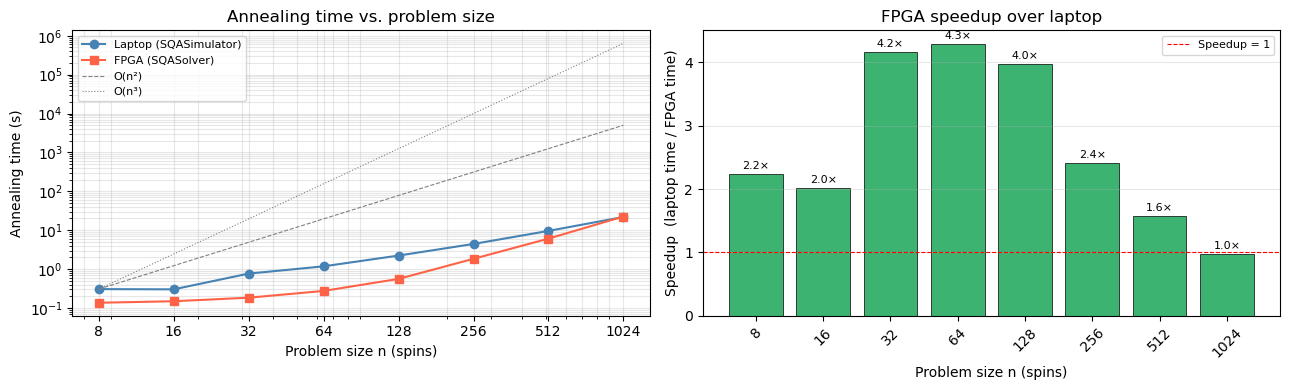

Saved benchmark_timing.png


In [4]:
# ── Plot 1: annealing time vs. problem size (log-log) + speedup ───────────────
ns = np.array(common_n, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — time vs n
ax = axes[0]
ax.loglog(ns, laptop['time_s'], 'o-', color='steelblue', label='Laptop (SQASimulator)')
ax.loglog(ns, fpga['time_s'],   's-', color='tomato',    label='FPGA (SQASolver)')

# O(n²) and O(n³) reference lines anchored to the first laptop point
for exp, ls, lbl in [(2, '--', 'O(n²)'), (3, ':', 'O(n³)')]:
    ref = (ns / ns[0]) ** exp * float(laptop['time_s'].iloc[0])
    ax.loglog(ns, ref, color='grey', linestyle=ls, linewidth=0.8, label=lbl)

ax.set_xlabel('Problem size n (spins)')
ax.set_ylabel('Annealing time (s)')
ax.set_title('Annealing time vs. problem size')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks(ns)
ax.grid(True, which='both', alpha=0.3)

# Right — speedup
ax2 = axes[1]
bars = ax2.bar(range(len(ns)), speedup.values,
               color='mediumseagreen', edgecolor='k', linewidth=0.5)
ax2.axhline(1.0, color='red', linewidth=0.8, linestyle='--', label='Speedup = 1')
ax2.set_xticks(range(len(ns)))
ax2.set_xticklabels([str(int(n)) for n in ns], rotation=45)
ax2.set_xlabel('Problem size n (spins)')
ax2.set_ylabel('Speedup  (laptop time / FPGA time)')
ax2.set_title('FPGA speedup over laptop')
ax2.legend(fontsize=8)
for bar, val in zip(bars, speedup.values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(speedup.values) * 0.01,
             f'{val:.1f}×', ha='center', va='bottom', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_timing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved benchmark_timing.png')

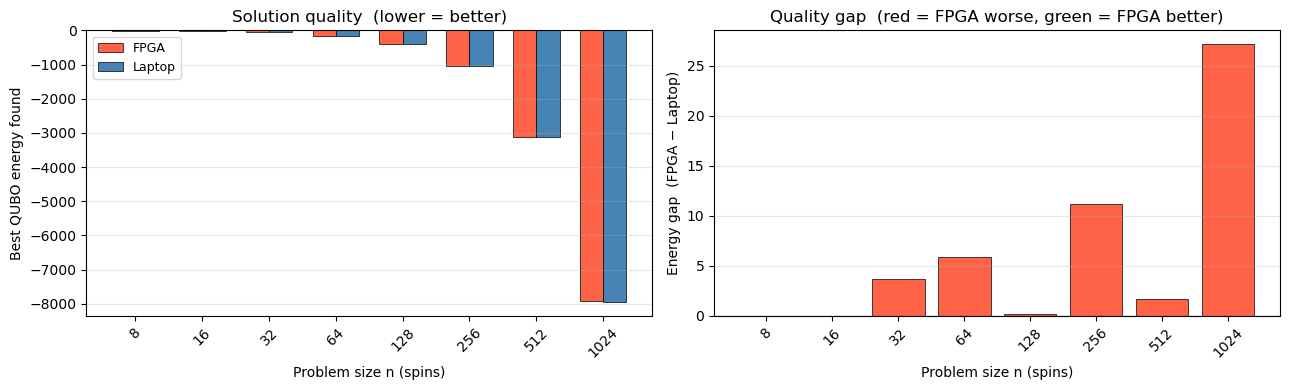

Saved benchmark_quality.png


In [5]:
# ── Plot 2: solution quality ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(len(ns))
w = 0.35

# Left — best energies side by side
ax = axes[0]
ax.bar(x - w/2, fpga['best_energy'],   width=w, label='FPGA',   color='tomato',    edgecolor='k', linewidth=0.5)
ax.bar(x + w/2, laptop['best_energy'], width=w, label='Laptop', color='steelblue', edgecolor='k', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([str(int(n)) for n in ns], rotation=45)
ax.set_xlabel('Problem size n (spins)')
ax.set_ylabel('Best QUBO energy found')
ax.set_title('Solution quality  (lower = better)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Right — energy gap
ax2 = axes[1]
colors = ['tomato' if g > 0 else 'mediumseagreen' for g in energy_gap]
ax2.bar(range(len(ns)), energy_gap.values, color=colors, edgecolor='k', linewidth=0.5)
ax2.axhline(0, color='k', linewidth=0.8)
ax2.set_xticks(range(len(ns)))
ax2.set_xticklabels([str(int(n)) for n in ns], rotation=45)
ax2.set_xlabel('Problem size n (spins)')
ax2.set_ylabel('Energy gap  (FPGA − Laptop)')
ax2.set_title('Quality gap  (red = FPGA worse, green = FPGA better)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved benchmark_quality.png')

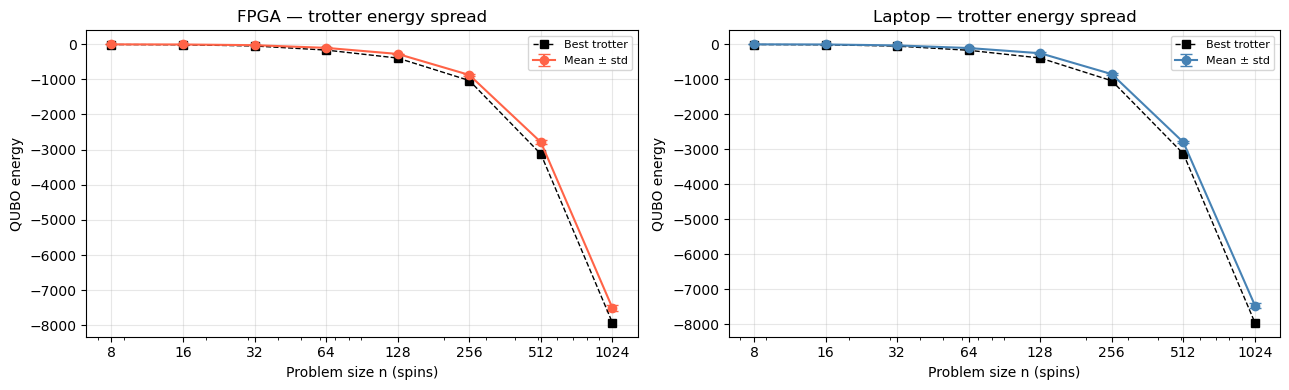

Saved benchmark_trotters.png


In [6]:
# ── Plot 3: trotter energy spread ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, label, color in [
    (axes[0], fpga,   'FPGA',   'tomato'),
    (axes[1], laptop, 'Laptop', 'steelblue'),
]:
    ax.errorbar(
        ns,
        df['trotter_mean'],
        yerr=df['trotter_std'],
        fmt='o-', color=color, capsize=4, linewidth=1.5, label='Mean ± std'
    )
    ax.plot(ns, df['best_energy'], 's--', color='k', linewidth=1, label='Best trotter')
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_xticks(ns)
    ax.set_xlabel('Problem size n (spins)')
    ax.set_ylabel('QUBO energy')
    ax.set_title(f'{label} — trotter energy spread')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_trotters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved benchmark_trotters.png')

---
## 2 — Iteration sweep comparison

Load `fpga_iter_sweep.csv` and `laptop_iter_sweep.csv` (same problem, n=64, varying iters).  
Shows how solution quality scales with iterations for each backend and whether  
the FPGA's lower per-iteration cost translates into better quality per unit of wall time.

In [7]:
FPGA_ITER_CSV   = 'fpga_iter_sweep.csv'
LAPTOP_ITER_CSV = 'laptop_iter_sweep.csv'

missing_iter = [f for f in (FPGA_ITER_CSV, LAPTOP_ITER_CSV) if not os.path.exists(f)]
if missing_iter:
    raise FileNotFoundError(
        f'Missing iteration-sweep files: {missing_iter}\n'
        'Run both benchmark notebooks with the iteration-sweep section first.'
    )

fpga_it   = pd.read_csv(FPGA_ITER_CSV)
laptop_it = pd.read_csv(LAPTOP_ITER_CSV)

common_iters = sorted(set(fpga_it['iters']) & set(laptop_it['iters']))
fpga_it   = fpga_it[fpga_it['iters'].isin(common_iters)].set_index('iters')
laptop_it = laptop_it[laptop_it['iters'].isin(common_iters)].set_index('iters')

print(f'Loaded {len(common_iters)} iteration counts: {common_iters}')

iter_summary = pd.DataFrame({
    'FPGA time (s)':   fpga_it['time_s'],
    'Laptop time (s)': laptop_it['time_s'],
    'Speedup (x)':     laptop_it['time_s'] / fpga_it['time_s'],
    'FPGA energy':     fpga_it['best_energy'],
    'Laptop energy':   laptop_it['best_energy'],
})
display(iter_summary.style.format({
    'FPGA time (s)':   '{:.4f}',
    'Laptop time (s)': '{:.4f}',
    'Speedup (x)':     '{:.1f}',
    'FPGA energy':     '{:.4f}',
    'Laptop energy':   '{:.4f}',
}))


Loaded 7 iteration counts: [50, 100, 200, 500, 1000, 2000, 5000]


,FPGA time (s),Laptop time (s),Speedup (x),FPGA energy,Laptop energy
iters,,,,,
50,0.2773,0.3193,1.2,-174.4524,-175.3142
100,0.2526,0.5102,2.0,-170.7481,-174.8423
200,0.2785,1.0160,3.6,-169.7596,-175.6495
500,0.3507,3.7471,10.7,-174.6683,-178.3240
1000,0.4745,6.8899,14.5,-172.5204,-178.1851
2000,0.7183,14.7889,20.6,-171.1294,-179.2276
5000,1.4546,30.3716,20.9,-172.6470,-178.5408


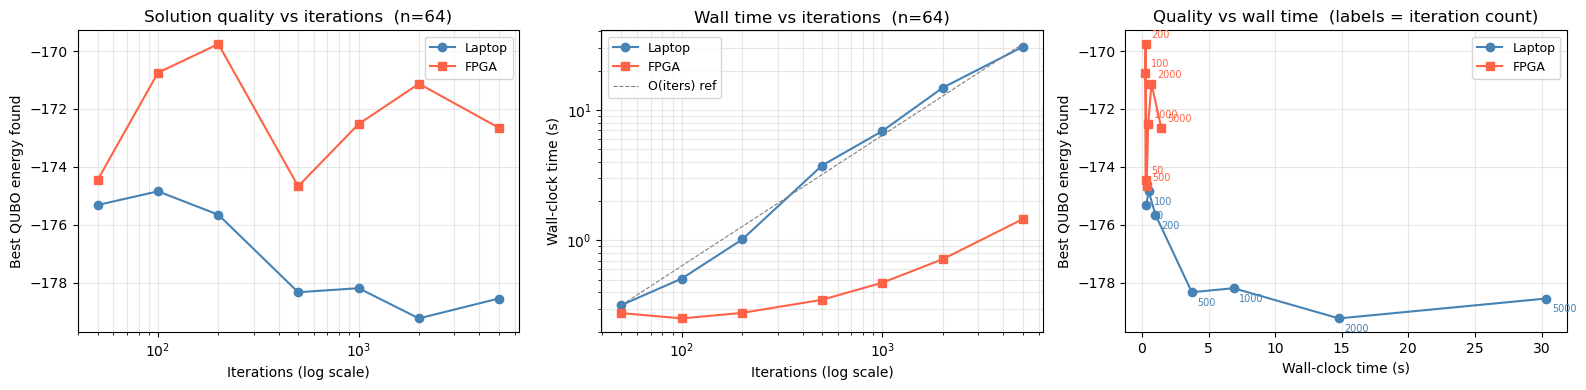

Saved benchmark_iters.png


In [8]:
iters_x  = np.array(common_iters, dtype=float)
fpga_e   = fpga_it['best_energy'].values
laptop_e = laptop_it['best_energy'].values
fpga_t   = fpga_it['time_s'].values
laptop_t = laptop_it['time_s'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left: energy vs iterations
ax = axes[0]
ax.semilogx(iters_x, laptop_e, 'o-', color='steelblue', label='Laptop')
ax.semilogx(iters_x, fpga_e,   's-', color='tomato',    label='FPGA')
ax.set_xlabel('Iterations (log scale)')
ax.set_ylabel('Best QUBO energy found')
ax.set_title('Solution quality vs iterations  (n=64)')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# Middle: wall time vs iterations
ax2 = axes[1]
ax2.loglog(iters_x, laptop_t, 'o-', color='steelblue', label='Laptop')
ax2.loglog(iters_x, fpga_t,   's-', color='tomato',    label='FPGA')
ref = (iters_x / iters_x[0]) * laptop_t[0]
ax2.loglog(iters_x, ref, '--', color='grey', linewidth=0.8, label='O(iters) ref')
ax2.set_xlabel('Iterations (log scale)')
ax2.set_ylabel('Wall-clock time (s)')
ax2.set_title('Wall time vs iterations  (n=64)')
ax2.legend(fontsize=9)
ax2.grid(True, which='both', alpha=0.3)

# Right: quality-per-second frontier
ax3 = axes[2]
ax3.plot(laptop_t, laptop_e, 'o-', color='steelblue', label='Laptop')
ax3.plot(fpga_t,   fpga_e,   's-', color='tomato',    label='FPGA')
for t, e, k in zip(fpga_t, fpga_e, common_iters):
    ax3.annotate(str(k), (t, e), textcoords='offset points',
                 xytext=(4, 4), fontsize=7, color='tomato')
for t, e, k in zip(laptop_t, laptop_e, common_iters):
    ax3.annotate(str(k), (t, e), textcoords='offset points',
                 xytext=(4, -10), fontsize=7, color='steelblue')
ax3.set_xlabel('Wall-clock time (s)')
ax3.set_ylabel('Best QUBO energy found')
ax3.set_title('Quality vs wall time  (labels = iteration count)')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_iters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved benchmark_iters.png')


---
## 3 — Restarts comparison

Load `fpga_restart_sweep.csv` and `laptop_restart_sweep.csv`.  
Shows how quality improves with more restarts for each backend,  
and whether the FPGA's speed advantage makes more restarts practical.

In [9]:
FPGA_RS_CSV   = 'fpga_restart_sweep.csv'
LAPTOP_RS_CSV = 'laptop_restart_sweep.csv'

missing_rs = [f for f in (FPGA_RS_CSV, LAPTOP_RS_CSV) if not os.path.exists(f)]
if missing_rs:
    raise FileNotFoundError(
        f'Missing restart-sweep files: {missing_rs}\n'
        'Run both benchmark notebooks section 2b first.'
    )

fpga_rs   = pd.read_csv(FPGA_RS_CSV).set_index('restarts')
laptop_rs = pd.read_csv(LAPTOP_RS_CSV).set_index('restarts')

common_rs = sorted(set(fpga_rs.index) & set(laptop_rs.index))
fpga_rs   = fpga_rs.loc[common_rs]
laptop_rs = laptop_rs.loc[common_rs]

rs_summary = pd.DataFrame({
    'FPGA time (s)':   fpga_rs['time_s'],
    'Laptop time (s)': laptop_rs['time_s'],
    'FPGA energy':     fpga_rs['best_energy'],
    'Laptop energy':   laptop_rs['best_energy'],
})
display(rs_summary.style.format({
    'FPGA time (s)':   '{:.4f}',
    'Laptop time (s)': '{:.4f}',
    'FPGA energy':     '{:.4f}',
    'Laptop energy':   '{:.4f}',
}))


,FPGA time (s),Laptop time (s),FPGA energy,Laptop energy
restarts,,,,
1,0.2784,1.0477,-169.7596,-175.6495
2,0.5495,2.1057,-176.4254,-175.7457
3,0.8190,2.9429,-176.4254,-176.9211
5,1.3644,7.9868,-176.4254,-177.1429
10,2.7605,12.3171,-176.4254,-178.0917


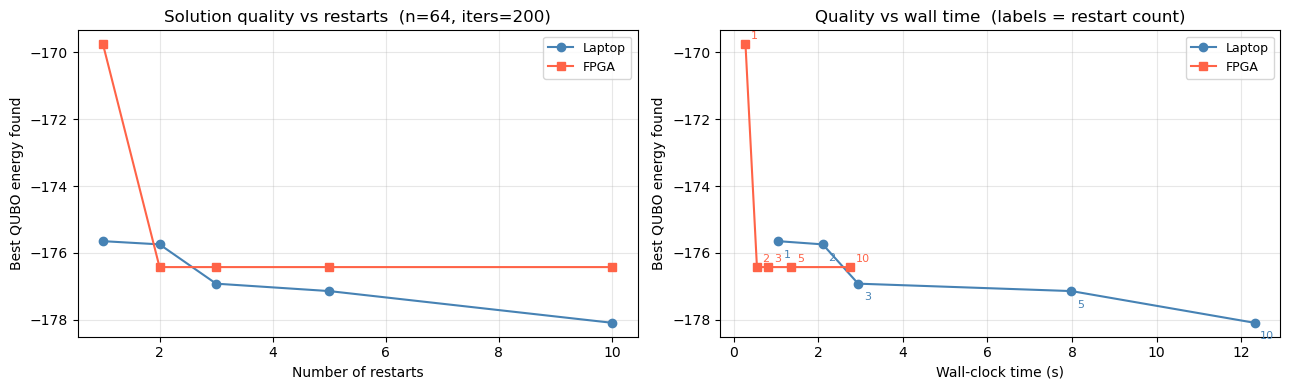

Saved benchmark_restarts.png


In [10]:
rs_arr      = np.array(common_rs, dtype=float)
fpga_re     = fpga_rs['best_energy'].values
laptop_re   = laptop_rs['best_energy'].values
fpga_rt     = fpga_rs['time_s'].values
laptop_rt   = laptop_rs['time_s'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(rs_arr, laptop_re, 'o-', color='steelblue', label='Laptop')
ax1.plot(rs_arr, fpga_re,   's-', color='tomato',    label='FPGA')
ax1.set_xlabel('Number of restarts')
ax1.set_ylabel('Best QUBO energy found')
ax1.set_title('Solution quality vs restarts  (n=64, iters=200)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(laptop_rt, laptop_re, 'o-', color='steelblue', label='Laptop')
ax2.plot(fpga_rt,   fpga_re,   's-', color='tomato',    label='FPGA')
for t, e, k in zip(fpga_rt, fpga_re, common_rs):
    ax2.annotate(f'{k}', (t, e), textcoords='offset points',
                 xytext=(4, 4), fontsize=8, color='tomato')
for t, e, k in zip(laptop_rt, laptop_re, common_rs):
    ax2.annotate(f'{k}', (t, e), textcoords='offset points',
                 xytext=(4, -12), fontsize=8, color='steelblue')
ax2.set_xlabel('Wall-clock time (s)')
ax2.set_ylabel('Best QUBO energy found')
ax2.set_title('Quality vs wall time  (labels = restart count)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_restarts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved benchmark_restarts.png')
